#### NFLH, SIF retrieval, and chlorophyll for one PACE granule

Set `GRANULE_ID` (e.g. `20250702T140322`), then run the cells below to open SVD retrieval output, L2 OC_AOP (`nflh`), L2 OC_BGC (`chlor_a`), and L1B true-color RGB (Mar05-style group open; NFLH/SIF on lon/lat pcolormesh) for map context. Optional third panel: TROPOMI SIF for `TROPOMI_ORBIT`.

In [138]:
from pathlib import Path
import glob
import re

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import h5py

# --- edit these for your machine ---
GRANULE_ID = "20250724T170203"

SVD_RETRIEVAL_DIR = Path("/home/zhe2/data/PACE/svd_retrieval_output")
L2_AOP_DIR = Path("/home/zhe2/data/PACE/L2_AOP_V3.1")
L2_BGC_DIR = Path("/home/zhe2/data/PACE/L2_BGC_V3.1")
L1B_DIR = Path("/home/zhe2/data/PACE/L1B_V3")

# L1B true-color bands (nm) from rhot_blue / rhot_red
RGB_WAVELENGTHS_NM = (443.0, 560.0, 665.0)

# Retrieval filename suffix after granule id, e.g. interim_<id>_svd_retrieval_full_gpu.nc
# Set to None to accept any interim_<id>_*.nc
SVD_RETRIEVAL_SUFFIX = "_svd_retrieval_full_parallel.nc"

# Map extent [lon_min, lon_max, lat_min, lat_max] (Plate Carrée)
BBOX = [-75.0, -65.0, 39.0, 43.5]

# Overlay chlor_a contours on NFLH/SIF maps
PLOT_CHL = False

# chlor_a contour levels (mg m^-3); set to None for auto levels inside the bbox
CHL_CONTOUR_LEVELS = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]

# Mask SIF pixels where L2 NFLH is missing (fill / invalid)
MASK_SIF_WHERE_NFLH_MISSING = True

# TROPOMI SIF (orbit -> fs_ret_<orbit>_b5_v10.h5)
TROPOMI_ORBIT = 40311
TROPOMI_RESULTS_DIR = Path("/kiwi-data/Data/groupMembers/zhe2/MyProjects/TROPOMI_SIF/results/b5")
TROPOMI_BAND = "b5"
TROPOMI_VERSION = "v10"
PLOT_TROPOMI = True
TROPOMI_GRID_N = 100
# If False, only require finite SIF/chi2 in bbox (ignore TROPOMI_QC_CUTS)
TROPOMI_APPLY_QC = True
# Manual QC on swath before gridding (None = skip that bound)
TROPOMI_QC_CUTS = {
    "sif_min": None,
    "sif_max": 2.0,
    "chi2_min": None,
    "chi2_max": 10.0,
}

# Shared color scale for all three map panels (None = auto 2–98% percentiles)
SHARED_CMAP = "PuBuGn"
SHARED_VMIN = -0.05
SHARED_VMAX = 0.5


In [139]:
_L2_AOP_RE = re.compile(r"^PACE_OCI\.(\d{8}T\d{6})\.L2\.OC_AOP.*\.nc$")
_L2_BGC_RE = re.compile(r"^PACE_OCI\.(\d{8}T\d{6})\.L2\.OC_BGC.*\.nc$")


def _coarse_prefix(gid: str) -> str:
    """Match retrieval/L2 times ignoring last two digits (seconds)."""
    return gid[:-2] if len(gid) >= 3 else gid


def find_svd_retrieval(
    granule_id: str,
    retrieval_dir: Path,
    suffix=None,
) -> Path:
    if suffix is not None:
        s = suffix if str(suffix).startswith("_") else f"_{suffix}"
        path = retrieval_dir / f"interim_{granule_id}{s}"
        if not path.is_file():
            raise FileNotFoundError(
                f"No SVD retrieval for granule {granule_id!r}: {path}"
            )
        return path

    pattern = str(retrieval_dir / f"interim_{granule_id}_*.nc")
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(
            f"No SVD retrieval for granule {granule_id!r} under {retrieval_dir}\n"
            f"  (glob: interim_{granule_id}_*.nc)"
        )
    if len(matches) > 1:
        print(f"Multiple retrieval files; using {matches[0]!r}")
    return Path(matches[0])


def resolve_l2_path(
    granule_id: str,
    l2_dir: Path,
    product: str,
    fname_re: re.Pattern,
) -> Path:
    """Exact PACE_OCI.<id>.L2.<product>.*.nc, else coarse second-level time match."""
    if product == "AOP":
        exact = l2_dir / f"PACE_OCI.{granule_id}.L2.OC_AOP.V3_1.nc"
    else:
        exact = l2_dir / f"PACE_OCI.{granule_id}.L2.OC_BGC.V3_1.nc"
    if exact.is_file():
        return exact

    prefix = _coarse_prefix(granule_id)
    candidates: list[tuple[Path, str]] = []
    for fname in l2_dir.iterdir():
        if not fname.name.endswith(".nc"):
            continue
        m = fname_re.match(fname.name)
        if m is None:
            continue
        l2_id = m.group(1)
        if _coarse_prefix(l2_id) == prefix:
            candidates.append((fname, l2_id))

    if not candidates:
        raise FileNotFoundError(
            f"No L2 {product} for granule {granule_id!r} in {l2_dir} (exact or coarse match)"
        )
    if len(candidates) == 1:
        path, l2_id = candidates[0]
        if l2_id != granule_id:
            print(f"L2 {product} coarse match: retrieval {granule_id} -> {l2_id} ({path.name})")
        return path

    def _sec_delta(l2_id: str) -> int:
        return abs(int(granule_id[-2:]) - int(l2_id[-2:]))

    path, l2_id = min(candidates, key=lambda t: _sec_delta(t[1]))
    print(f"L2 {product} coarse match (closest seconds): {granule_id} -> {l2_id} ({path.name})")
    return path


def open_l2_merged(path: Path, decode_timedelta: bool = True) -> xr.Dataset:
    """Open PACE L2 NetCDF (possibly grouped) as one flat Dataset."""
    tree = xr.open_datatree(path, decode_timedelta=decode_timedelta)
    return xr.merge(tree.to_dict().values())


def resolve_l1b_path(granule_id: str, l1b_dir: Path = L1B_DIR) -> Path:
    exact = l1b_dir / f"PACE_OCI.{granule_id}.L1B.V3.nc"
    if exact.is_file():
        return exact
    prefix = _coarse_prefix(granule_id)
    candidates = []
    for p in l1b_dir.glob("PACE_OCI.*.L1B.V3.nc"):
        m = re.search(r"PACE_OCI\.(\d{8}T\d{6})\.L1B", p.name)
        if m and _coarse_prefix(m.group(1)) == prefix:
            candidates.append(p)
    if not candidates:
        raise FileNotFoundError(f"No L1B for granule {granule_id} in {l1b_dir}")
    if len(candidates) == 1:
        return candidates[0]
    return min(
        candidates,
        key=lambda p: abs(
            int(granule_id[-2:])
            - int(re.search(r"(\d{8}T\d{6})", p.name).group(1)[-2:])
        ),
    )


def open_l1b_oci(l1b_path: Path):
    """PACE L1B V3: open groups and merge obs with geolocation (L1data_Mar05)."""
    band = xr.open_dataset(l1b_path, group="sensor_band_parameters")
    geo = xr.open_dataset(l1b_path, group="geolocation_data")
    obs = xr.open_dataset(l1b_path, group="observation_data")
    oci = geo.set_coords(("longitude", "latitude"))
    oci = xr.merge((obs, oci.coords))
    return band, geo, obs, oci


def subset_l1b_oci(oci: xr.Dataset, bbox) -> xr.Dataset:
    lon0, lon1, lat0, lat1 = bbox
    condition = (
        (oci.coords["latitude"] >= lat0)
        & (oci.coords["latitude"] <= lat1)
        & (oci.coords["longitude"] >= lon0)
        & (oci.coords["longitude"] <= lon1)
    )
    return oci.where(condition, drop=True)


def _nearest_band_index(wavelengths: xr.DataArray, target_nm: float) -> int:
    wl = wavelengths.values.astype(float)
    return int(np.abs(wl - target_nm).argmin())


def _enhance_rhot(chan: np.ndarray, p_lo: float, p_hi: float) -> np.ndarray:
    out = chan.astype(float)
    invalid = ~np.isfinite(out) | (out <= 0)
    out[invalid] = np.nan
    vals = out[np.isfinite(out)]
    if vals.size == 0:
        return np.zeros_like(out)
    lo, hi = np.nanpercentile(vals, [p_lo, p_hi])
    scaled = (out - lo) / max(hi - lo, 1e-6)
    scaled = np.clip(scaled, 0, 1)
    scaled[invalid] = np.nan
    return scaled


def build_l1b_true_color(
    flo: xr.Dataset,
    band: xr.Dataset,
    rgb_nm=RGB_WAVELENGTHS_NM,
    p_lo=2.0,
    p_hi=98.0,
):
    """lon, lat (scans, pixels) and RGB in [0, 1] from subset oci (Mar05 flo)."""
    ib = _nearest_band_index(band["blue_wavelength"], rgb_nm[0])
    ig = _nearest_band_index(band["blue_wavelength"], rgb_nm[1])
    ir = _nearest_band_index(band["red_wavelength"], rgb_nm[2])

    b = flo["rhot_blue"].isel(blue_bands=ib).values
    g = flo["rhot_blue"].isel(blue_bands=ig).values
    r = flo["rhot_red"].isel(red_bands=ir).values
    lon = flo["longitude"].values.astype(float)
    lat = flo["latitude"].values.astype(float)

    rgb = np.stack(
        [
            _enhance_rhot(r, p_lo, p_hi),
            _enhance_rhot(g, p_lo, p_hi),
            _enhance_rhot(b, p_lo, p_hi),
        ],
        axis=-1,
    )
    meta = {
        "red_nm": float(band["red_wavelength"].isel(red_bands=ir).values),
        "green_nm": float(band["blue_wavelength"].isel(blue_bands=ig).values),
        "blue_nm": float(band["blue_wavelength"].isel(blue_bands=ib).values),
    }
    return lon, lat, rgb, meta


def plot_l1b_true_color(ax, lon, lat, rgb, extent, stride=2):
    """L1B true-color swath via imshow on geographic extent."""
    st = max(1, int(stride))
    sl = slice(None, None, st)
    lon_s = np.asarray(lon[sl, sl], dtype=float)
    lat_s = np.asarray(lat[sl, sl], dtype=float)
    rgb_s = np.clip(np.nan_to_num(np.asarray(rgb[sl, sl, :], dtype=float), nan=0.0), 0, 1)
    geo_extent = [
        np.nanmin(lon_s),
        np.nanmax(lon_s),
        np.nanmin(lat_s),
        np.nanmax(lat_s),
    ]
    ax.imshow(
        rgb_s,
        origin="lower",
        extent=geo_extent,
        transform=ccrs.PlateCarree(),
        interpolation="nearest",
        zorder=0,
    )
    ax.set_extent(extent, crs=ccrs.PlateCarree())


def mask_sif_missing_nflh(sif, nflh, fill=-999.0):
    """Drop SIF pixels where NFLH is missing or invalid (same swath grid)."""
    sif_out = np.asarray(sif, dtype=float).copy()
    nflh_a = np.asarray(nflh, dtype=float)
    if sif_out.shape != nflh_a.shape:
        raise ValueError(f"SIF {sif_out.shape} and NFLH {nflh_a.shape} must match")
    nflh_missing = (
        ~np.isfinite(nflh_a)
        | (nflh_a == fill)
        | (nflh_a < -900)
    )
    bad = nflh_missing | ~np.isfinite(sif_out)
    sif_out[bad] = np.nan
    return sif_out, int(nflh_missing.sum())




def resolve_tropomi_h5(orbit, results_dir, band="b5", version="v10") -> Path:
    path = Path(results_dir) / f"fs_ret_{orbit}_{band}_{version}.h5"
    if not path.is_file():
        raise FileNotFoundError(f"TROPOMI retrieval not found: {path}")
    return path


def load_grid_tropomi_sif(h5_path, bbox, cuts=None, n_grid=100, apply_qc=True):
    """Read TROPOMI RETRIEVAL_RESULT, optional QC-filter, bin to lat/lon grid inside bbox."""
    lon_min, lon_max, lat_min, lat_max = bbox
    with h5py.File(h5_path, "r") as f:
        if "RETRIEVAL_RESULT" not in f:
            raise KeyError(f"No RETRIEVAL_RESULT in {h5_path}; keys={list(f.keys())}")
        rr = f["RETRIEVAL_RESULT"]
        lat_b = rr["latitude"][:]
        lon_b = rr["longitude"][:]
        sif = rr["sif"][:]
        chi2 = rr["chi2"][:]

    region = (
        (lat_b > lat_min) & (lat_b < lat_max)
        & (lon_b > lon_min) & (lon_b < lon_max)
    )
    lat_r = lat_b[region]
    lon_r = lon_b[region]
    sif_r = sif[region]
    chi2_r = chi2[region]

    valid = np.isfinite(sif_r) & np.isfinite(chi2_r)
    if apply_qc and cuts is not None:
        if cuts.get("sif_min") is not None:
            valid &= sif_r >= cuts["sif_min"]
        if cuts.get("sif_max") is not None:
            valid &= sif_r <= cuts["sif_max"]
        if cuts.get("chi2_min") is not None:
            valid &= chi2_r >= cuts["chi2_min"]
        if cuts.get("chi2_max") is not None:
            valid &= chi2_r <= cuts["chi2_max"]

    lat_r = lat_r[valid]
    lon_r = lon_r[valid]
    sif_r = sif_r[valid]

    n_lat = int(n_grid)
    n_lon = int(n_grid)
    lat_bins = np.linspace(lat_min, lat_max, n_lat + 1)
    lon_bins = np.linspace(lon_min, lon_max, n_lon + 1)
    sif_grid = np.full((n_lat, n_lon), np.nan)
    count_grid = np.zeros((n_lat, n_lon))

    lat_idx = np.searchsorted(lat_bins, lat_r, side="right") - 1
    lon_idx = np.searchsorted(lon_bins, lon_r, side="right") - 1
    in_grid = (lat_idx >= 0) & (lat_idx < n_lat) & (lon_idx >= 0) & (lon_idx < n_lon)
    for i in np.where(in_grid)[0]:
        la, lo = lat_idx[i], lon_idx[i]
        if np.isnan(sif_grid[la, lo]):
            sif_grid[la, lo] = sif_r[i]
            count_grid[la, lo] = 1
        else:
            sif_grid[la, lo] += sif_r[i]
            count_grid[la, lo] += 1

    with np.errstate(invalid="ignore", divide="ignore"):
        sif_grid = sif_grid / np.where(count_grid == 0, np.nan, count_grid)

    lon_edges, lat_edges = np.meshgrid(lon_bins, lat_bins)
    if np.isfinite(sif_grid).any():
        vmin = float(np.nanpercentile(sif_grid, 1))
        vmax = float(np.nanpercentile(sif_grid, 99))
    else:
        vmin, vmax = 0.0, 1.0
    return lon_edges, lat_edges, sif_grid, vmin, vmax


def plot_tropomi_sif_panel(
    ax,
    lon_edges,
    lat_edges,
    sif_grid,
    extent,
    vmin,
    vmax,
    title,
    cmap="PuBuGn",
    lon_l1b=None,
    lat_l1b=None,
    rgb_l1b=None,
):
    from matplotlib.colors import Normalize

    if lon_l1b is not None:
        plot_l1b_true_color(ax, lon_l1b, lat_l1b, rgb_l1b, extent, stride=2)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    mesh = None
    if np.isfinite(sif_grid).any():
        mesh = ax.pcolormesh(
            lon_edges,
            lat_edges,
            sif_grid,
            cmap=cmap,
            norm=Normalize(vmin=vmin, vmax=vmax),
            shading="auto",
            transform=ccrs.PlateCarree(),
            alpha=0.82 if lon_l1b is not None else 1.0,
            zorder=2,
        )
    ax.set_title(title)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    return mesh

def plot_l1b_band_mar05(
    ax,
    flo: xr.Dataset,
    band: xr.Dataset,
    band_dim: str,
    band_idx: int,
    extent,
    levels=None,
):
    """Single-band rhot map (L1data_Mar05: pcolormesh + BoundaryNorm)."""
    levels = levels or [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
    norm = BoundaryNorm(levels, ncolors=256)
    if band_dim == "red_bands":
        da = flo["rhot_red"].sel(red_bands=band_idx)
        wv = float(band["red_wavelength"].isel(red_bands=band_idx).values)
    else:
        da = flo["rhot_blue"].sel(blue_bands=band_idx)
        wv = float(band["blue_wavelength"].isel(blue_bands=band_idx).values)
    da.plot.pcolormesh(
        x="longitude",
        y="latitude",
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        norm=norm,
        add_colorbar=False,
        zorder=2,
    )
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(f"rhot @ {wv:.1f} nm")


In [140]:
svd_path = find_svd_retrieval(GRANULE_ID, SVD_RETRIEVAL_DIR, SVD_RETRIEVAL_SUFFIX)
l2aop_path = resolve_l2_path(GRANULE_ID, L2_AOP_DIR, "AOP", _L2_AOP_RE)
l2bgc_path = resolve_l2_path(GRANULE_ID, L2_BGC_DIR, "BGC", _L2_BGC_RE)

print("SVD retrieval:", svd_path)
print("L2 AOP:       ", l2aop_path)
print("L2 BGC:       ", l2bgc_path)

ds_sif = xr.open_dataset(svd_path)
ds_l2aop = open_l2_merged(l2aop_path)
ds_l2bgc = open_l2_merged(l2bgc_path)

l1b_path = resolve_l1b_path(GRANULE_ID)
band_l1b, geo_l1b, obs_l1b, oci_l1b = open_l1b_oci(l1b_path)
flo_l1b = subset_l1b_oci(oci_l1b, BBOX)
lon_l1b, lat_l1b, rgb_l1b, rgb_meta = build_l1b_true_color(flo_l1b, band_l1b)
print("L1B:", l1b_path)
print("L1B RGB bands (nm):", rgb_meta)

SVD retrieval: /home/zhe2/data/PACE/svd_retrieval_output/interim_20250724T170203_svd_retrieval_full_parallel.nc
L2 AOP:        /home/zhe2/data/PACE/L2_AOP_V3.1/PACE_OCI.20250724T170203.L2.OC_AOP.V3_1.nc
L2 BGC:        /home/zhe2/data/PACE/L2_BGC_V3.1/PACE_OCI.20250724T170203.L2.OC_BGC.V3_1.nc
L1B: /home/zhe2/data/PACE/L1B_V3/PACE_OCI.20250724T170203.L1B.V3.nc
L1B RGB bands (nm): {'red_nm': 664.5294189453125, 'green_nm': 560.0540161132812, 'blue_nm': 442.2808837890625}


In [141]:
# Swath arrays (scans × pixels; NFLH and SIF share L2 swath shape)
nflh = ds_l2aop["nflh"].values
lat_aop = ds_l2aop["latitude"].values
lon_aop = ds_l2aop["longitude"].values

sif_678 = ds_sif["sif_radiance_678nm"].values.astype(float)
if MASK_SIF_WHERE_NFLH_MISSING:
    sif_678, n_sif_masked = mask_sif_missing_nflh(sif_678, nflh)
    print(f"SIF QC: masked {n_sif_masked} px (NFLH missing/invalid)")
lat_sif = ds_sif["latitude"].values
lon_sif = ds_sif["longitude"].values

chlor_a = ds_l2bgc["chlor_a"].values
lat_bgc = ds_l2bgc["latitude"].values
lon_bgc = ds_l2bgc["longitude"].values

print("SIF shape:", sif_678.shape, "  nflh:", nflh.shape, "  chlor_a:", chlor_a.shape)

tropomi_lon_edges = tropomi_lat_edges = tropomi_sif_grid = None
tropomi_vmin = tropomi_vmax = 0.0
if PLOT_TROPOMI:
    trop_path = resolve_tropomi_h5(
        TROPOMI_ORBIT, TROPOMI_RESULTS_DIR, TROPOMI_BAND, TROPOMI_VERSION
    )
    trop_cuts = TROPOMI_QC_CUTS if TROPOMI_APPLY_QC else None
    tropomi_lon_edges, tropomi_lat_edges, tropomi_sif_grid, tropomi_vmin, tropomi_vmax = (
        load_grid_tropomi_sif(
            trop_path, BBOX, trop_cuts, n_grid=TROPOMI_GRID_N, apply_qc=TROPOMI_APPLY_QC
        )
    )
    qc_msg = f"cuts {trop_cuts}" if TROPOMI_APPLY_QC else "no QC (finite only)"
    print("TROPOMI:", trop_path.name, f"grid {tropomi_sif_grid.shape}", qc_msg)


SIF QC: masked 1022193 px (NFLH missing/invalid)
SIF shape: (1710, 1272)   nflh: (1710, 1272)   chlor_a: (1710, 1272)
TROPOMI: fs_ret_40311_b5_v10.h5 grid (100, 100) cuts {'sif_min': None, 'sif_max': 2.0, 'chi2_min': None, 'chi2_max': 10.0}


In [144]:
def _mask_fill(arr, fill=None):
    a = np.asarray(arr, dtype=float)
    if fill is None:
        fill = -999.0
    bad = ~np.isfinite(a) | (a == fill) | (a < -900)
    return np.ma.masked_where(bad, a)




def _values_in_extent(field, lon, lat, extent):
    lon0, lon1, lat0, lat1 = extent
    m = (
        np.isfinite(lon) & np.isfinite(lat)
        & (lon >= lon0) & (lon <= lon1)
        & (lat >= lat0) & (lat <= lat1)
    )
    arr = field.filled(np.nan) if np.ma.isMaskedArray(field) else np.asarray(field, dtype=float)
    v = arr[m]
    return v[np.isfinite(v)]


def _shared_color_limits(arrays, p_lo=2, p_hi=98, vmin=None, vmax=None):
    """Common vmin/vmax for all panels; use SHARED_VMIN/SHARED_VMAX or percentiles."""
    if vmin is not None and vmax is not None:
        return float(vmin), float(vmax)
    parts = []
    for a in arrays:
        if a is None:
            continue
        v = np.asarray(a, dtype=float).ravel()
        v = v[np.isfinite(v)]
        if v.size:
            parts.append(v)
    if not parts:
        return 0.0, 1.0
    allv = np.concatenate(parts)
    return float(np.nanpercentile(allv, p_lo)), float(np.nanpercentile(allv, p_hi))


def _auto_chl_levels(chl, lon, lat, extent, n=6):
    lon0, lon1, lat0, lat1 = extent
    m = (
        np.isfinite(lon) & np.isfinite(lat)
        & (lon >= lon0) & (lon <= lon1)
        & (lat >= lat0) & (lat <= lat1)
    )
    v = chl[m]
    v = v.compressed() if hasattr(v, "compressed") else v[np.isfinite(v)]
    v = v[(v > 0) & (v < 100)]
    if v.size < 10:
        return np.array([0.1, 0.5, 1.0, 2.0])
    qs = np.quantile(v, np.linspace(0.15, 0.85, n))
    return np.unique(np.round(qs, 3))


def _swath_dataarray(field, lon, lat):
    """2D field with lon/lat coordinates for xarray pcolormesh (Mar05)."""
    if np.ma.isMaskedArray(field):
        values = field.filled(np.nan)
    else:
        values = np.asarray(field, dtype=float)
    ny, nx = values.shape
    return xr.DataArray(
        values,
        coords={
            "longitude": (("y", "x"), lon),
            "latitude": (("y", "x"), lat),
        },
        dims=("y", "x"),
    )


def _plot_field_pcolormesh(ax, lon, lat, field, cmap, vmin, vmax, alpha=1.0):
    da = _swath_dataarray(field, lon, lat)
    return da.plot.pcolormesh(
        x="longitude",
        y="latitude",
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        alpha=alpha,
        add_colorbar=False,
        zorder=2,
    )


def _add_map_panel(
    ax, lon, lat, field, title, cmap, vmin, vmax, extent,
    chl=None, chl_levels=None, plot_chl=False,
    lon_l1b=None, lat_l1b=None, rgb_l1b=None,
):
    if lon_l1b is not None:
        plot_l1b_true_color(ax, lon_l1b, lat_l1b, rgb_l1b, extent, stride=2)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    mesh = _plot_field_pcolormesh(
        ax, lon, lat, field, cmap, vmin, vmax,
        alpha=0.99 if lon_l1b is not None else 1.0,
    )
    if plot_chl and chl is not None and chl_levels is not None:
        chl_plot = chl.filled(np.nan) if np.ma.isMaskedArray(chl) else np.asarray(chl, dtype=float)
        cs = ax.contour(
            lon, lat, chl_plot,
            levels=chl_levels,
            colors="k",
            linewidths=0.7,
            transform=ccrs.PlateCarree(),
        )
        ax.clabel(cs, inline=True, fontsize=8, fmt="%.2g")
    ax.set_title(title)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    return mesh


Shared colorbar: PuBuGn [-0.05, 0.5]


/tmp/ipykernel_682976/3506177352.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


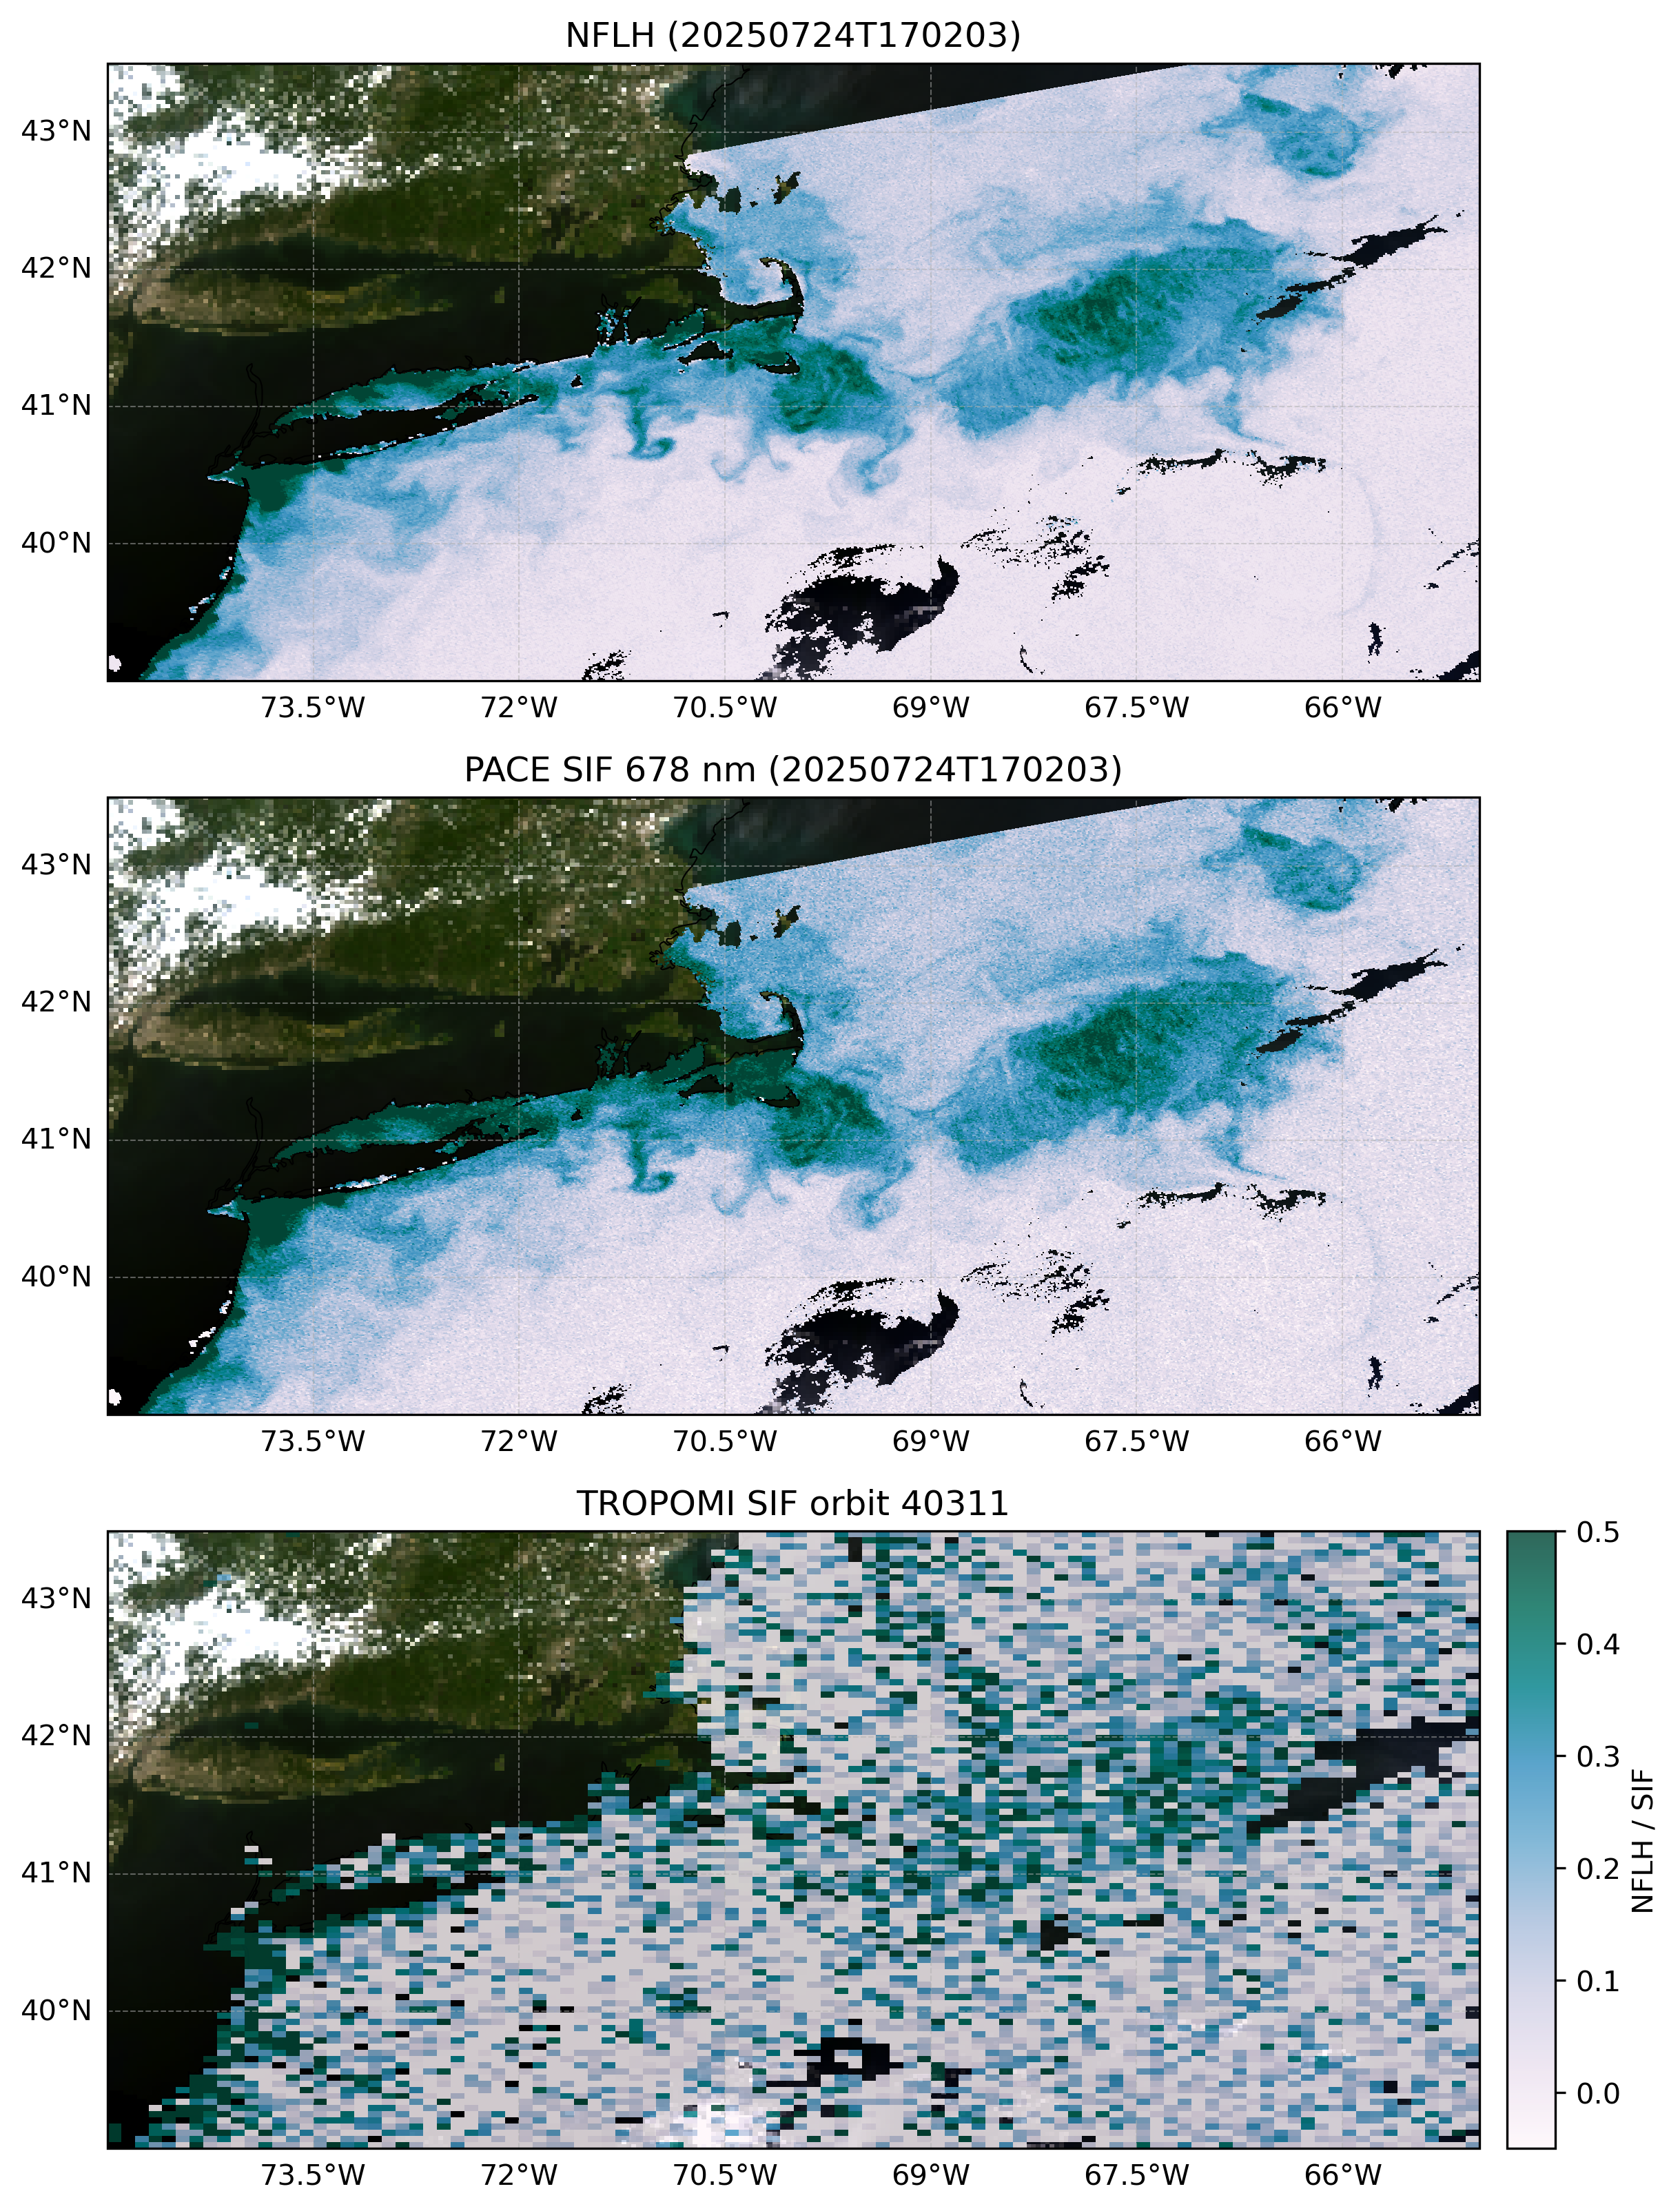

In [147]:

extent = list(BBOX)
lon = lon_aop
lat = lat_aop

nflh_m = _mask_fill(nflh)
sif_m = _mask_fill(sif_678)
chl_m = _mask_fill(chlor_a) if PLOT_CHL else None
chl_levels = None
if PLOT_CHL:
    chl_levels = (
        list(CHL_CONTOUR_LEVELS)
        if CHL_CONTOUR_LEVELS is not None
        else _auto_chl_levels(chl_m, lon, lat, extent).tolist()
    )

# 3×1 maps: NFLH, PACE SIF, (optionally) TROPOMI SIF (shared colorbar)
cbar_arrays = [
    _values_in_extent(nflh_m, lon, lat, extent),
    _values_in_extent(sif_m, lon_sif, lat_sif, extent),
]
if PLOT_TROPOMI and tropomi_sif_grid is not None:
    cbar_arrays.append(tropomi_sif_grid.ravel())
cbar_vmin, cbar_vmax = _shared_color_limits(
    cbar_arrays, vmin=SHARED_VMIN, vmax=SHARED_VMAX
)
print(f"Shared colorbar: {SHARED_CMAP} [{cbar_vmin:.4g}, {cbar_vmax:.4g}]")

# Compute figure height for real lat/lon ratio
lat_min, lat_max, lon_min, lon_max = extent[2], extent[3], extent[0], extent[1]
lat_span = abs(lat_max - lat_min)
lon_span = abs(lon_max - lon_min)
aspect_ratio = lat_span / lon_span if lon_span > 0 else 1.0
n_rows = 3 if (PLOT_TROPOMI and tropomi_sif_grid is not None) else 2
base_width = 8  # can adjust as needed for font size
panel_aspect = aspect_ratio
panel_height = base_width * panel_aspect
fig_height = panel_height * n_rows

# Set space for colorbar outside the panels: make the figure wider
cbar_width_inch = 0.5
fig_width = base_width + cbar_width_inch + 0.5

fig, axes = plt.subplots(
    nrows=n_rows, ncols=1,
    figsize=(fig_width, fig_height),
    subplot_kw=dict(projection=ccrs.PlateCarree()),
    dpi=300,
)

# Ensure axes is always a 1D array for easy indexing, even for n_rows=1
if n_rows == 1:
    axes = [axes]
else:
    axes = axes.flatten().tolist()

ax_nflh = axes[0]
ax_sif = axes[1]
mesh0 = _add_map_panel(
    ax_nflh, lon, lat, nflh_m, f"NFLH ({GRANULE_ID})", SHARED_CMAP, cbar_vmin, cbar_vmax,
    extent, chl=chl_m, chl_levels=chl_levels, plot_chl=PLOT_CHL,
    lon_l1b=lon_l1b, lat_l1b=lat_l1b, rgb_l1b=rgb_l1b,
)
mesh1 = _add_map_panel(
    ax_sif, lon_sif, lat_sif, sif_m, f"PACE SIF 678 nm ({GRANULE_ID})", SHARED_CMAP, cbar_vmin, cbar_vmax,
    extent, chl=chl_m, chl_levels=chl_levels, plot_chl=PLOT_CHL,
    lon_l1b=lon_l1b, lat_l1b=lat_l1b, rgb_l1b=rgb_l1b,
)

mesh_cbar = mesh1

if n_rows == 3:
    ax_trop = axes[2]
    mesh2 = plot_tropomi_sif_panel(
        ax_trop,
        tropomi_lon_edges,
        tropomi_lat_edges,
        tropomi_sif_grid,
        extent,
        cbar_vmin,
        cbar_vmax,
        f"TROPOMI SIF orbit {TROPOMI_ORBIT}",
        cmap=SHARED_CMAP,
        lon_l1b=lon_l1b,
        lat_l1b=lat_l1b,
        rgb_l1b=rgb_l1b,
    )
    if mesh2 is not None:
        mesh_cbar = mesh2

# Put colorbar outside all map panels, rightmost, using inset_axes instead of make_axes_locatable for GeoAxes.

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Use the last axis for colorbar location.
cax = inset_axes(
    axes[-1],
    width="3.5%",
    height="100%",
    loc="lower left",
    bbox_to_anchor=(1.02, 0., 1, 1),
    bbox_transform=axes[-1].transAxes,
    borderpad=0,
)

cb = fig.colorbar(
    mesh_cbar,
    cax=cax,
    orientation="vertical",
    label="NFLH / SIF",
)

if PLOT_CHL:
    fig.suptitle(f"chlor_a contours: {chl_levels}", y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

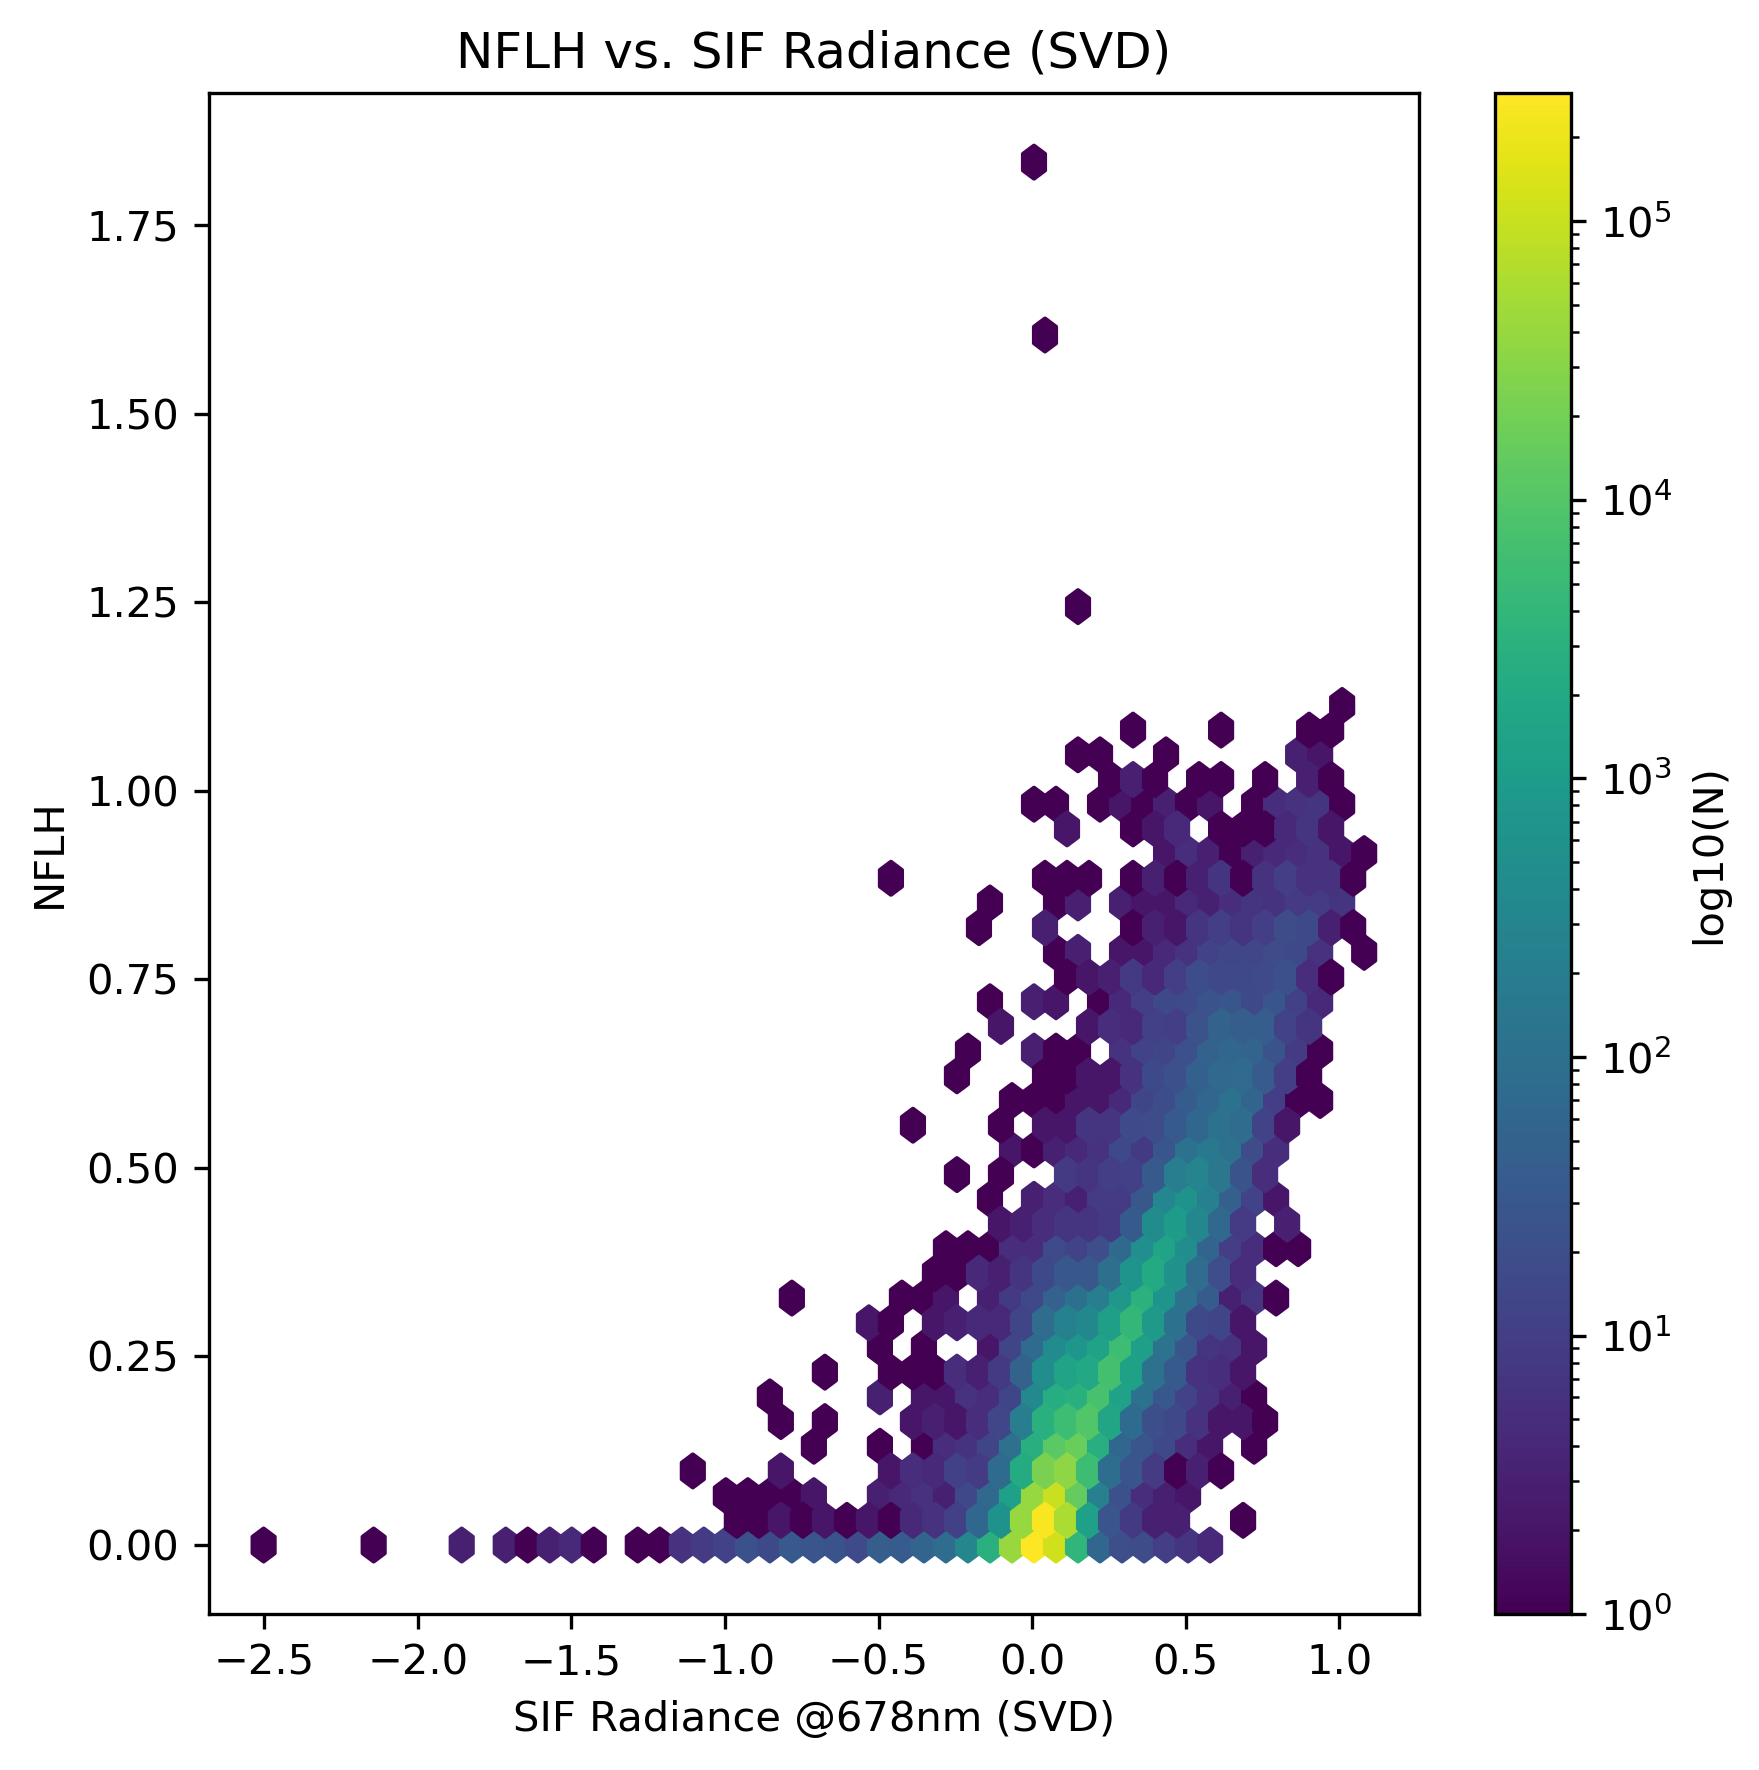

In [150]:
# Side-by-side scatterplots: nflh vs. sif_678_svd and nflh vs. sif_678_xsec (xsec)
fig, ax = plt.subplots(figsize=(6, 6), sharex=True, sharey=True, dpi=300)

# First plot: nflh vs. sif_678_svd (remove NaN from either)
x1 = sif_678.flatten()
y1 = nflh.flatten()
valid_mask1 = ~np.isnan(x1) & ~np.isnan(y1)
x1_valid = x1[valid_mask1]
y1_valid = y1[valid_mask1]
hb1 = ax.hexbin(x1_valid, y1_valid, gridsize=50, cmap='viridis', bins='log')
ax.set_xlabel('SIF Radiance @678nm (SVD)')
ax.set_ylabel('NFLH')
ax.set_title('NFLH vs. SIF Radiance (SVD)')
cb1 = fig.colorbar(hb1, ax=ax)
cb1.set_label('log10(N)')

plt.tight_layout()
plt.show()